In [55]:
import os
from dotenv import load_dotenv

In [58]:
load_dotenv()

True

In [62]:
print(os.getenv("GOOGLE_API_KEY"))
print(os.getenv("NOTION_API_KEY"))
print(os.getenv("NOTION_CALENDAR_DB_ID"))
print(os.getenv("NOTION_NOTES_DB_ID"))

In [63]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [64]:
llm = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash-lite')

In [65]:
llm.invoke('hi there')

AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPQJRPJKggxmjJM2dz+wTf5ghwTc713SXonaLi0sEujx4ho8TQyE7S6H4XsADSaMSJHQVS6QSUXt2Eepfk6NooyoaQhH/sQeTtpPtgW87UrotLQqI4DWCg'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ff65d-2cb6-7b41-aba4-b94b8b5196a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 10, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [66]:
from langchain_groq import ChatGroq

In [67]:
llm_g = ChatGroq(model = 'llama-3.1-8b-instant',max_tokens = 128)

In [68]:
llm_g.invoke('diffusion model in ai')

AIMessage(content='**Diffusion Models in AI**\n\nDiffusion models are a class of deep learning algorithms that have gained significant attention in recent years, particularly in the field of generative modeling. They have been widely used in various applications such as image and video synthesis, audio generation, and data compression.\n\n**What are Diffusion Models?**\n\nDiffusion models are a type of generative model that learn to represent data as a sequence of noise-contrastive distributions. They work by iteratively adding noise to the input data, and at each step, the model predicts the probability of the noisy data given the previous noise level. The goal is to learn a', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 40, 'total_tokens': 168, 'completion_time': 0.204634369, 'completion_tokens_details': None, 'prompt_time': 0.002355845, 'prompt_tokens_details': None, 'queue_time': 0.047411475, 'total_time': 0.206990214}, 'model_

In [69]:
from langchain.agents import create_agent

In [70]:
my_tools = []
my_agent = create_agent(model = llm_g,tools = my_tools)

In [71]:
my_agent.invoke({'messages':[('user','hi there')]})

{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='15f8135e-b3b2-496b-8dab-8639b01ba0c8'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.01381795, 'completion_tokens_details': None, 'prompt_time': 0.002430815, 'prompt_tokens_details': None, 'queue_time': 0.047268451, 'total_time': 0.016248765}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff65d-3a91-7553-8b16-91d6632f18fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}

In [72]:
my_agent.invoke({
    "messages": [
        {"role": "user", "content": "hi there"}
    ]
})

{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='bcb6826a-fecb-4fbd-8679-59e01a0618f6'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.013855349, 'completion_tokens_details': None, 'prompt_time': 0.002233258, 'prompt_tokens_details': None, 'queue_time': 0.047564021, 'total_time': 0.016088607}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff65d-3bfe-7dd2-bc9e-007fc058a6a2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}

In [73]:
from langchain.tools import tool

In [74]:
@tool
def dummy_tool(inputText:str)-> str:
    """
    Convert input text to upper case. This is just for testing.
    Arguments:
        inputText {str} - input text to be concverted to uppercase
    """
    return f"Outptu: {inputText.upper()}"



In [75]:
tools = [dummy_tool]
agent_with_dummy_tool = create_agent(model = llm_g,tools = tools)

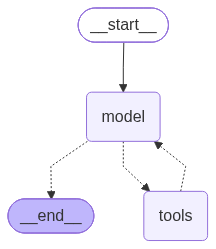

In [76]:
agent_with_dummy_tool

In [77]:
import requests

In [78]:
@tool
def get_weather(city:str) -> str:
    """Get the weather for a given city"""
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_data = requests.get(geo_url).json()

        if not geo_data.get('results'):
            return {"error":f"City '{city}' not found"}

        location = geo_data['results'][0]
        lat, lon = location['latitude'], location['longitude']

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,weather_code"
        data = requests.get(weather_url).json()
        
        temp = data['current']['temperature_2m']
        return {'city':city,'temp':temp,'unit':'C'}

    except Exception as e:
        return {'error':str(e)}



In [79]:
print(get_weather.invoke('kaithal'))

{'city': 'kaithal', 'temp': 31.2, 'unit': 'C'}


In [80]:
tools = [dummy_tool,get_weather]

weather_agent = create_agent(model = llm_g,tools = tools)

In [85]:
weather_agent.invoke({'messages':[('user','get the weather of kaithal using the tools')]})

In [ ]:
weather_agent.invoke({'messages':[('user','get the weather of kaithal using the tools and convert the response to upper case')]})

{'messages': [HumanMessage(content='get the weather of kaithal using the tools and convert the response to upper case', additional_kwargs={}, response_metadata={}, id='4b4539bf-f913-4264-baaf-13e4a6560c5a'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '30g265tdn', 'function': {'arguments': '{"city":"Kaithal"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'vq84gy2fq', 'function': {'arguments': '{"inputText":"the weather of Kaithal is rainy and cloudy today"}', 'name': 'dummy_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 334, 'total_tokens': 375, 'completion_time': 0.083578179, 'completion_tokens_details': None, 'prompt_time': 0.027653072, 'prompt_tokens_details': None, 'queue_time': 0.047740721, 'total_time': 0.111231251}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'gro

Notes Tool


In [107]:
@tool
def get_notes() -> list:
    """
    Get all pending notes from notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = f"https://api.notion.com/v1/databases/{db_id}/query"

    payload = {
        "filter":{
            "property":"Status",
            "select":{
                "equals":"Pending"
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        data = res.json()

        notes = []
        for page in data.get("results",[]):
            props = page.get("properties",{})
            title_list = props.get("Note",{}).get("title",{})
            node_content = title_list[0].get("text",{}).get("content","") if title_list else "Untitled Note"
            notes.append(node_content)
        
        return notes
    
    except Exception as e:
        return [f"Error Fetching Notes: {str(e)}"]


In [108]:
@tool
def add_note(note:str) -> str:
    """
    Add a new note to Notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = "https://api.notion.com/v1/pages"

    payload = {
        "parent" : {"database_id":db_id},
        "properties" : {
            "Note" : {
                "title" : [{"text":{"content":note}}]
            },
            "Status" : {
                "select" : {"name" : "Pending"}
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        return f"Note added successfully: {note}"
    
    except Exception as e:
        return f"Error adding note: {str(e)}"
    

In [109]:
get_notes.invoke("")

[]

In [110]:
notes_tools = [get_notes, add_note]

In [111]:
notion_notes_agent = create_agent(model = llm_g, tools=notes_tools)

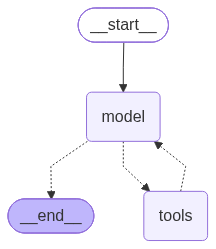

In [112]:
notion_notes_agent

In [119]:
notion_notes_agent.invoke({'messages':[('user','Add a note in notion to do llm finutuing project tomorrow')]})

{'messages': [HumanMessage(content='Add a note in notion to do llm finutuing project tomorrow', additional_kwargs={}, response_metadata={}, id='be572cd0-0f12-4177-89b0-e8283f22634d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gtzn879jt', 'function': {'arguments': '{"note":"LLM Finutuing project tomorrow"}', 'name': 'add_note'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 270, 'total_tokens': 290, 'completion_time': 0.035814229, 'completion_tokens_details': None, 'prompt_time': 0.01663081, 'prompt_tokens_details': None, 'queue_time': 0.158851593, 'total_time': 0.052445039}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6d7-0d06-7593-8fcb-347d29d7951c-0', tool_calls=[{'name': 'add_note', 'args': {'note': 'LLM Finutuing project tomorrow'}, 'id': 'gtzn879jt', '

In [120]:
notion_notes_agent.invoke({'messages':[('user','Tell me the current notes I have in my notion')]})

{'messages': [HumanMessage(content='Tell me the current notes I have in my notion', additional_kwargs={}, response_metadata={}, id='8e7962a8-b461-4864-9078-4562dbf6ba39'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ktrcafa3d', 'function': {'arguments': '{}', 'name': 'get_notes'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 266, 'total_tokens': 274, 'completion_time': 0.008692558, 'completion_tokens_details': None, 'prompt_time': 0.016388695, 'prompt_tokens_details': None, 'queue_time': 0.047602128, 'total_time': 0.025081253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6d7-2d46-79d3-9151-4c6bbeece37a-0', tool_calls=[{'name': 'get_notes', 'args': {}, 'id': 'ktrcafa3d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 266, 'output